# HARV 2D Tutorial

This notebook is a first walkthrough of the current `SBM_Bioreactor` code. It shows how the 2D HARV example is assembled, what equations are being solved, what the initial data look like, and how a coarse transient run evolves.

The goal is understanding, not production performance. We intentionally use a coarse mesh and short run so the full workflow is visible.

## Governing Equations

The current implementation advances a monolithic five-field system for
$$\mathbf{u},\; p,\; \Phi,\; C,\; \Gamma,$$
where $\mathbf{u}$ is the mixture velocity, $p$ is pressure, $\Phi$ is the cell volume fraction, $C$ is the nutrient concentration, and $\Gamma$ is a projected shear-rate field.

At a high level, the code solves
$$\rho(\Phi)\,\partial_t \mathbf{u} + \rho(\Phi) (\mathbf{u}\cdot\nabla)\mathbf{u} = -\nabla p + \nabla\cdot\big(\mu(\Phi)\nabla \mathbf{u}\big) + \rho(\Phi)\,\mathbf{g} + \text{Hele-Shaw drag},$$
$$\nabla\cdot\mathbf{u} = \frac{\rho_s-\rho_f}{\rho_s\rho_f}\,\nabla\cdot\mathbf{J}_s,$$
$$\partial_t \Phi + \mathbf{u}\cdot\nabla\Phi = \frac{\rho_s-\rho_f}{\rho_s\rho_f}\,\nabla\cdot\mathbf{J}_s - S_\Phi(C,t),$$
$$\partial_t C + \mathbf{u}\cdot\nabla C = D_f\nabla^2 C - r_c(\Phi),$$
$$\Gamma \approx \sqrt{2\,\varepsilon(\mathbf{u}):\varepsilon(\mathbf{u})}. $$

The nonlinearity comes from the concentration-dependent viscosity and the suspension-balance particle flux.

In [2]:
using SBM_Bioreactor
using Gridap
using Plots
include(joinpath(pwd(), "..", "scripts", "visualize.jl"))

demo_harv_visualization (generic function with 1 method)

In [3]:
case = build_harv_2d_case(partition=(12, 12), dt=0.2, total_time=1.0, degree=2)
tutorial_params = merge(case.params, (use_explicit_jacobian=true,))
radius = case.metadata.radius
times = 0.0:case.metadata.dt:case.metadata.total_time


0.0:0.2:1.0

## Geometry and Mesh

The tutorial uses a square computational box mapped to a disk. This keeps setup simple while still giving a circular HARV-like domain. The plot below shows the mapped structured mesh used by Gridap.

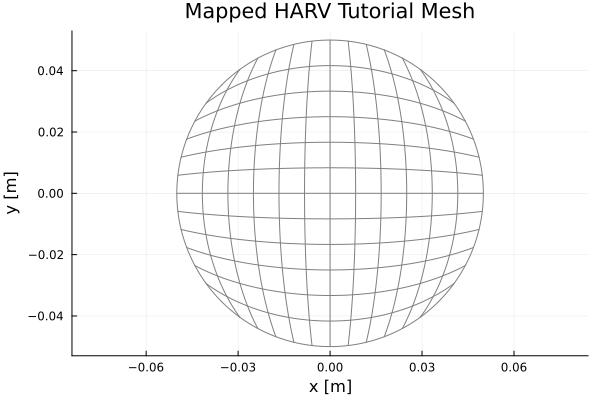

In [4]:
display(plot_harv_mesh(case))

## Initial and Boundary Data

The outer wall rotates with angular speed $\omega$, while the initial cell field starts as a simple top-half cloud. Below we sample the tutorial input fields on a regular plotting grid.

In [5]:
xs, ys, phi0 = sample_scalar_field(case.params.Φ0; radius=radius)
_, _, c0 = sample_scalar_field(case.params.C0; radius=radius)

(-0.05:0.0008333333333333334:0.05, -0.05:0.0008333333333333334:0.05, [NaN NaN … NaN NaN; NaN NaN … NaN NaN; … ; NaN NaN … NaN NaN; NaN NaN … NaN NaN])

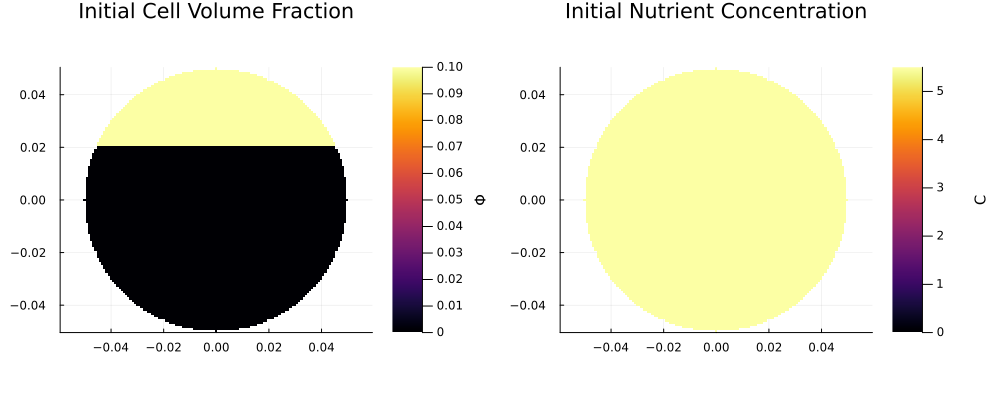

In [6]:
plot_initial_conditions(case)

## Coarse Transient Run

We now run a deliberately coarse simulation and keep the full in-memory history. This is enough to see the workflow and generate simple visualizations, but it should not be treated as a converged scientific result.

In [ ]:
result = run_bioreactor_simulation(
    case.X,
    case.Y,
    case.dΩ,
    case.metadata.dt,
    tutorial_params,
    case.metadata.nsteps;
    collect_history=true,
    write_vtk_interval=0,
    output_prefix="notebooks/artifacts/harv_tutorial",
    nonlinear_show_trace=false,
    max_order=1
)

final_state = result.final_state
phi_history = [state[3] for state in result.history]


In [ ]:
plot_scalar_history_snapshots(phi_history, result.times; radius=radius, colorbar_title="Φ", label="Φ")

## Animation Export

The next cell writes a coarse GIF and attempts an MP4 export. The GIF should work in a standard Plots setup; MP4 support depends on the local `ffmpeg` backend.

In [ ]:
mkpath("notebooks/artifacts")
animate_scalar_history(phi_history, result.times; radius=radius, output_path="notebooks/artifacts/harv_2d_phi.gif", fps=4, colorbar_title="Φ", label="HARV tutorial: Φ")

In [ ]:
try
    animate_scalar_history(phi_history, result.times; radius=radius, output_path="notebooks/artifacts/harv_2d_phi.mp4", fps=4, colorbar_title="Φ", label="HARV tutorial: Φ")
catch err
    @warn "MP4 export failed; GIF export is still available." err
end

## Interpretation and Limits

This notebook is a first tutorial, not a validation study. The mesh is coarse, the runtime is short, and the goal is to show how the code is organized. For scientific use, you would next want mesh refinement, timestep sensitivity, MMS verification, and physically motivated parameter studies.